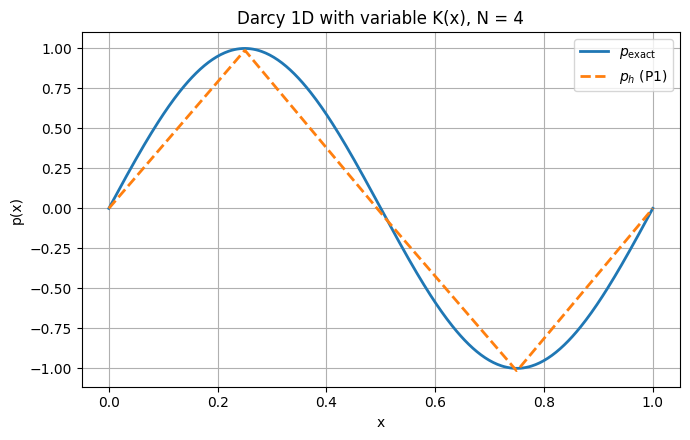

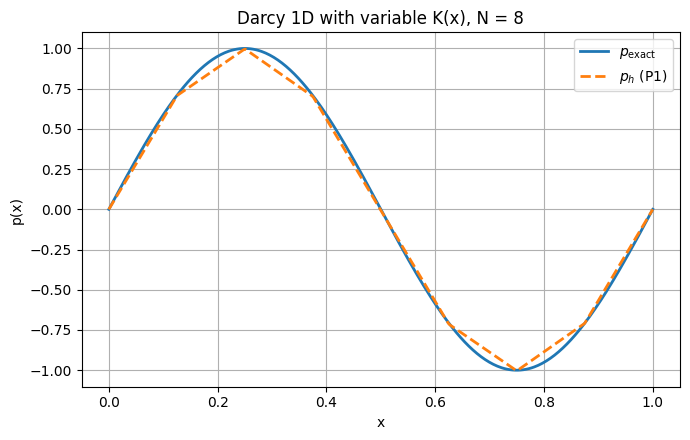

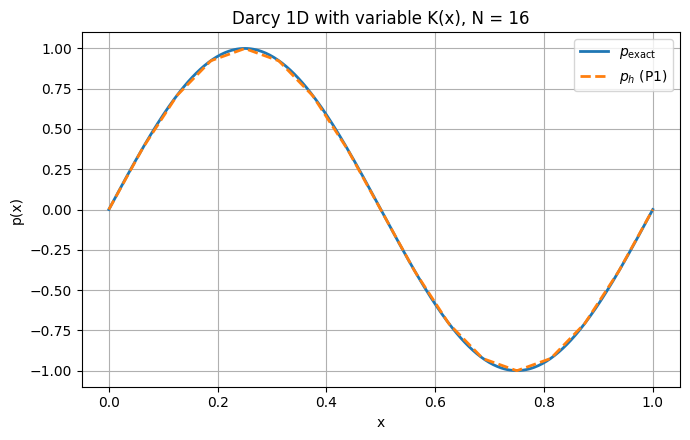

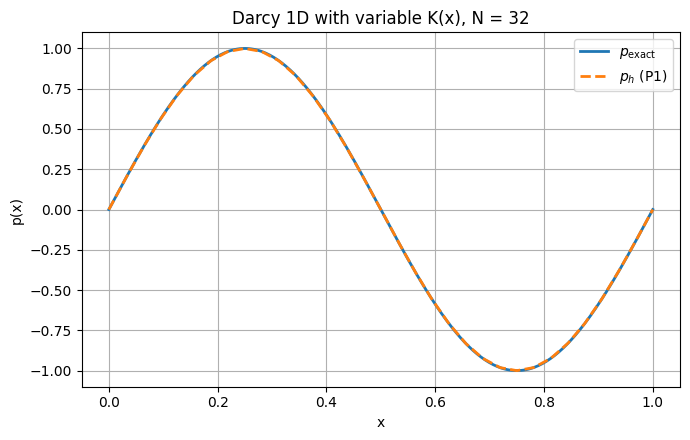

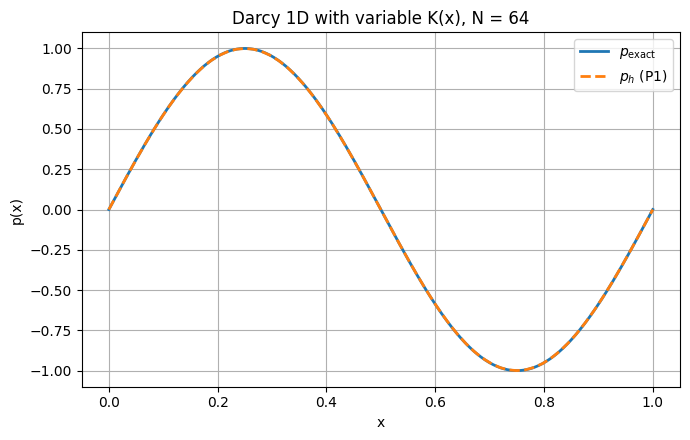

       N            h         ||e||_L2     rate(L2)           |e|_H1     rate(H1)
----------------------------------------------------------------------------------
       4 2.500000e-01   1.50463757e-01          ---   1.93460567e+00          ---
       8 1.250000e-01   3.92085750e-02     1.940175   9.97138754e-01     0.956173
      16 6.250000e-02   9.90313092e-03     1.985213   5.02379059e-01     0.989018
      32 3.125000e-02   2.48211910e-03     1.996312   2.51668266e-01     0.997253
      64 1.562500e-02   6.20926189e-04     1.999079   1.25894054e-01     0.999313


In [41]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
from math import log
import matplotlib.pyplot as plt
import math

from dolfinx import fem, mesh, geometry
from dolfinx.fem.petsc import LinearProblem
import ufl


def exact_p_array(x):
    # x has shape (gdim, num_points)
    return np.sin(2 * np.pi * x[0])


def solve_darcy_1d(ncells: int):
    """
    Solve
        -(K(x) p')' = f  on (0,1),
    with
        K(x) = 2 + x^2,
        p_exact(x) = sin(2*pi*x),
        f(x) = 4*pi^2*(2 + x^2)*sin(2*pi*x) - 4*pi*x*cos(2*pi*x).
    """
    comm = MPI.COMM_WORLD

    # Mesh
    domain = mesh.create_interval(comm, ncells, [0.0, 1.0])

    # P2 space
    V = fem.functionspace(domain, ("Lagrange", 1))

    # Trial and test functions
    p = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    x = ufl.SpatialCoordinate(domain)

    # Variable permeability
    K = 2.0 + x[0] ** 2

    # Exact forcing for p_exact = sin(2*pi*x)
    f = (
        4 * math.pi**2 * (2.0 + x[0] ** 2) * ufl.sin(2 * math.pi * x[0])
        - 4 * math.pi * x[0] * ufl.cos(2 * math.pi * x[0])
    )

    # Weak form: ∫ K p' v' dx = ∫ f v dx
    a = K * ufl.inner(ufl.grad(p), ufl.grad(v)) * ufl.dx
    L = f * v * ufl.dx

    # Boundary markers
    def left_boundary(x):
        return np.isclose(x[0], 0.0)

    def right_boundary(x):
        return np.isclose(x[0], 1.0)

    left_dofs = fem.locate_dofs_geometrical(V, left_boundary)
    right_dofs = fem.locate_dofs_geometrical(V, right_boundary)

    # p_exact(0)=0 and p_exact(1)=0
    p_left = fem.Constant(domain, PETSc.ScalarType(0.0))
    p_right = fem.Constant(domain, PETSc.ScalarType(0.0))

    bc_left = fem.dirichletbc(p_left, left_dofs, V)
    bc_right = fem.dirichletbc(p_right, right_dofs, V)
    bcs = [bc_left, bc_right]

    # Solve
    problem = LinearProblem(
        a,
        L,
        bcs=bcs,
        petsc_options_prefix=f"darcy1d_{ncells}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    ph = problem.solve()
    ph.name = "p_h"

    # Higher-order space for error computation
    W = fem.functionspace(domain, ("Lagrange", 4))

    p_exact_h = fem.Function(W)
    p_exact_h.interpolate(exact_p_array)

    ph_high = fem.Function(W)
    ph_high.interpolate(ph)

    # L2 error
    e_L2_form = fem.form((ph_high - p_exact_h) ** 2 * ufl.dx)
    e_L2 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_L2_form), op=MPI.SUM))

    # H1 seminorm error
    e_H1_form = fem.form(
        ufl.inner(ufl.grad(ph_high - p_exact_h), ufl.grad(ph_high - p_exact_h)) * ufl.dx
    )
    e_H1 = np.sqrt(comm.allreduce(fem.assemble_scalar(e_H1_form), op=MPI.SUM))

    h = 1.0 / ncells
    return domain, ph, h, e_L2, e_H1


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        r = log(errors[i - 1] / errors[i]) / log(hs[i - 1] / hs[i])
        rates.append(r)
    return rates


def plot_solution(domain, ph, ncells):
    """
    Plot p_h and p_exact on a fine set of points in [0,1].
    """
    comm = domain.comm
    rank = comm.rank

    # Fine plotting points
    x_plot = np.linspace(0.0, 1.0, 400, dtype=np.float64)
    points = np.zeros((len(x_plot), 3), dtype=np.float64)
    points[:, 0] = x_plot

    # Locate cells containing the points
    tree = geometry.bb_tree(domain, domain.topology.dim)
    cell_candidates = geometry.compute_collisions_points(tree, points)
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, points)

    points_on_proc = []
    cells = []
    x_local = []

    for i, point in enumerate(points):
        cell_list = colliding_cells.links(i)
        if len(cell_list) > 0:
            points_on_proc.append(point)
            cells.append(cell_list[0])
            x_local.append(x_plot[i])

    points_on_proc = np.array(points_on_proc, dtype=np.float64)
    x_local = np.array(x_local, dtype=np.float64)

    if len(points_on_proc) > 0:
        ph_vals_local = ph.eval(points_on_proc, cells).flatten()
        # pexact_vals_local = x_local * (1.0 - x_local)
        pexact_vals_local = np.sin(2*math.pi*x_local)
    else:
        ph_vals_local = np.array([], dtype=np.float64)
        pexact_vals_local = np.array([], dtype=np.float64)

    gathered_x = comm.gather(x_local, root=0)
    gathered_ph = comm.gather(ph_vals_local, root=0)
    gathered_pe = comm.gather(pexact_vals_local, root=0)

    if rank == 0:
        x_all = np.concatenate(gathered_x)
        ph_all = np.concatenate(gathered_ph)
        pe_all = np.concatenate(gathered_pe)

        idx = np.argsort(x_all)
        x_all = x_all[idx]
        ph_all = ph_all[idx]
        pe_all = pe_all[idx]

        plt.figure(figsize=(7, 4.5))
        plt.plot(x_all, pe_all, label=r"$p_{\mathrm{exact}}$", linewidth=2)
        plt.plot(x_all, ph_all, "--", label=r"$p_h$ (P1)", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("p(x)")
        plt.title(f"Darcy 1D with variable K(x), N = {ncells}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    mesh_sizes = [4, 8, 16, 32, 64]

    hs = []
    L2_errors = []
    H1_errors = []

    for n in mesh_sizes:
        domain, ph, h, eL2, eH1 = solve_darcy_1d(n)

        hs.append(h)
        L2_errors.append(eL2)
        H1_errors.append(eH1)

        # Plot p_h and p_exact for each mesh
        plot_solution(domain, ph, n)

    L2_rates = convergence_rate(L2_errors, hs)
    H1_rates = convergence_rate(H1_errors, hs)

    if MPI.COMM_WORLD.rank == 0:
        print(f"{'N':>8} {'h':>12} {'||e||_L2':>16} {'rate(L2)':>12} {'|e|_H1':>16} {'rate(H1)':>12}")
        print("-" * 82)
        for i, n in enumerate(mesh_sizes):
            rL2 = "---" if L2_rates[i] is None else f"{L2_rates[i]:.6f}"
            rH1 = "---" if H1_rates[i] is None else f"{H1_rates[i]:.6f}"
            print(
                f"{n:8d} {hs[i]:12.6e} {L2_errors[i]:16.8e} {rL2:>12} "
                f"{H1_errors[i]:16.8e} {rH1:>12}"
            )


Max abs local conservation error = 3.170241111313024


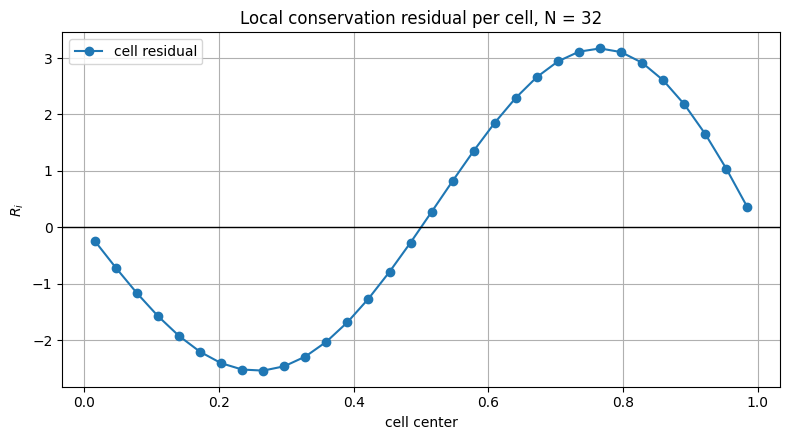

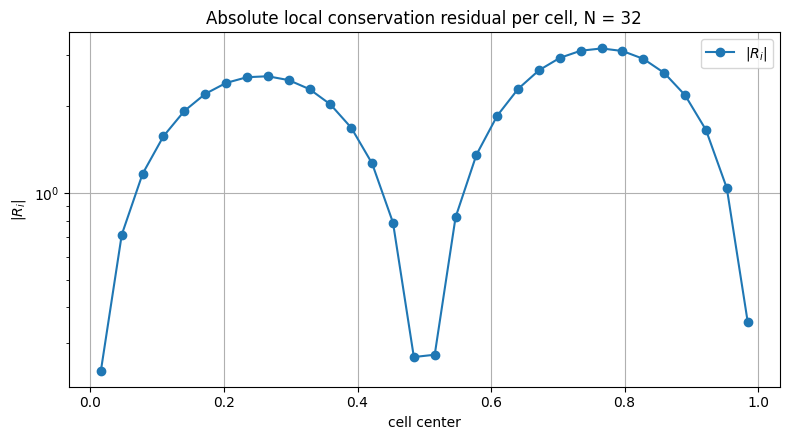

In [42]:
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import matplotlib.pyplot as plt

from dolfinx import fem, mesh
import ufl


def compute_local_conservation_error(domain, ph):
    """
    Compute cellwise local conservation residuals
        R_i = q_h(x_{i+1}^-) - q_h(x_i^+) - ∫_{K_i} f dx
    with q_h = -K(x) p_h'(x).

    Returns
    -------
    cell_centers : np.ndarray
    residuals    : np.ndarray
    abs_residuals: np.ndarray
    """
    V = ph.function_space
    comm = domain.comm
    tdim = domain.topology.dim

    # Ensure cell-vertex connectivity exists
    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    # P1 dof coordinates
    x_dofs = V.tabulate_dof_coordinates()[:, 0]
    u = ph.x.array

    num_cells_local = domain.topology.index_map(tdim).size_local

    cell_centers_local = np.zeros(num_cells_local, dtype=np.float64)
    residuals_local = np.zeros(num_cells_local, dtype=np.float64)

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)
        x_cell = x_dofs[cell_dofs]
        u_cell = u[cell_dofs]

        # Sort because local ordering is not something to assume blindly
        idx = np.argsort(x_cell)
        x0, x1 = x_cell[idx]
        p0, p1 = u_cell[idx]

        h = x1 - x0
        dpdx = (p1 - p0) / h   # constant on a P1 cell

        # Correct permeability and source
        def Kfun(x):
            return 2.0 + x**2
            # return 1

        # IMPORTANT: use corrected f
        def fint_exact(a, b):
            # ∫ (4 - 2x + 6x^2) dx from a to b
            # return (4.0*b - b**2 + 2.0*b**3) - (4.0*a - a**2 + 2.0*a**3)
            return 2 * math.pi * (
                    (2 + a**2) * math.cos(2 * math.pi * a)
                    - (2 + b**2) * math.cos(2 * math.pi * b)
    )

        # One-sided fluxes from inside this cell
        q_left = -Kfun(x0) * dpdx
        q_right = -Kfun(x1) * dpdx

        # Local conservation residual
        residual = q_right - q_left - fint_exact(x0, x1)

        cell_centers_local[cell] = 0.5 * (x0 + x1)
        residuals_local[cell] = residual

    # Gather to rank 0 for plotting
    gathered_centers = comm.gather(cell_centers_local, root=0)
    gathered_residuals = comm.gather(residuals_local, root=0)

    if comm.rank == 0:
        cell_centers = np.concatenate(gathered_centers)
        residuals = np.concatenate(gathered_residuals)

        idx = np.argsort(cell_centers)
        cell_centers = cell_centers[idx]
        residuals = residuals[idx]
        abs_residuals = np.abs(residuals)

        return cell_centers, residuals, abs_residuals

    return None, None, None


def plot_local_conservation_error(cell_centers, residuals, abs_residuals, N):
    plt.figure(figsize=(8, 4.5))
    plt.plot(cell_centers, residuals, "o-", label="cell residual")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("cell center")
    plt.ylabel(r"$R_i$")
    plt.title(f"Local conservation residual per cell, N = {N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.semilogy(cell_centers, abs_residuals, "o-", label=r"$|R_i|$")
    plt.xlabel("cell center")
    plt.ylabel(r"$|R_i|$")
    plt.title(f"Absolute local conservation residual per cell, N = {N}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    N = 32

    # Make sure solve_darcy_1d uses the corrected source:
    # f = 4.0 - 2.0*x[0] + 6.0*x[0]**2
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    cell_centers, residuals, abs_residuals = compute_local_conservation_error(domain, ph)

    if MPI.COMM_WORLD.rank == 0:
        # print(f"{'cell center':>14} {'residual':>18} {'abs(residual)':>18}")
        # print("-" * 54)
        # for xc, r, ar in zip(cell_centers, residuals, abs_residuals):
        #     print(f"{xc:14.6e} {r:18.10e} {ar:18.10e}")

        print("\nMax abs local conservation error =", np.max(abs_residuals))
        plot_local_conservation_error(cell_centers, residuals, abs_residuals, N)

Epoch     0 | loss = 2.213112e+01 | pde = 2.213112e+01 | reg = 0.000000e+00
Epoch   500 | loss = 1.999402e+01 | pde = 1.999397e+01 | reg = 4.916103e-03
Epoch  1000 | loss = 1.567838e+01 | pde = 1.567786e+01 | reg = 5.197359e-02
Epoch  1500 | loss = 1.063863e+01 | pde = 1.063658e+01 | reg = 2.043853e-01
Epoch  2000 | loss = 6.428025e+00 | pde = 6.423136e+00 | reg = 4.888810e-01
Epoch  2500 | loss = 3.707651e+00 | pde = 3.699036e+00 | reg = 8.615331e-01
Epoch  3000 | loss = 2.314660e+00 | pde = 2.302334e+00 | reg = 1.232569e+00
Epoch  3500 | loss = 1.689145e+00 | pde = 1.674129e+00 | reg = 1.501599e+00
Epoch  4000 | loss = 1.308059e+00 | pde = 1.291734e+00 | reg = 1.632457e+00
Epoch  4500 | loss = 9.516713e-01 | pde = 9.348549e-01 | reg = 1.681640e+00
Epoch  5000 | loss = 6.121191e-01 | pde = 5.949930e-01 | reg = 1.712610e+00
Epoch  5500 | loss = 3.399740e-01 | pde = 3.225483e-01 | reg = 1.742577e+00
Epoch  6000 | loss = 1.717089e-01 | pde = 1.539923e-01 | reg = 1.771653e+00
Epoch  6500 

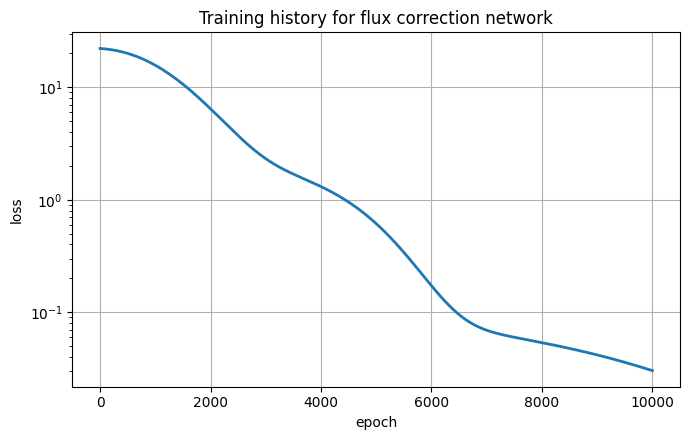

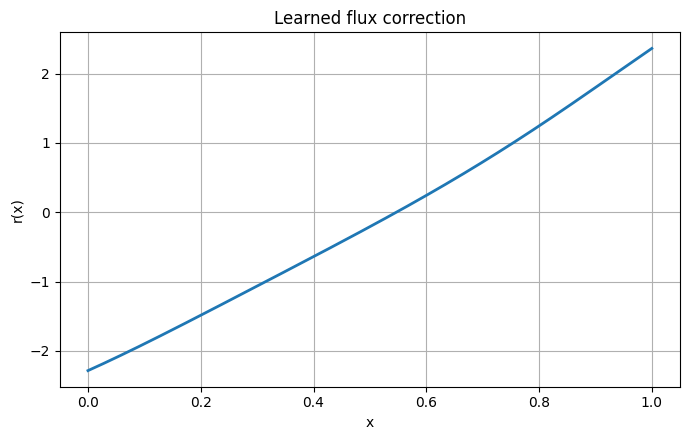

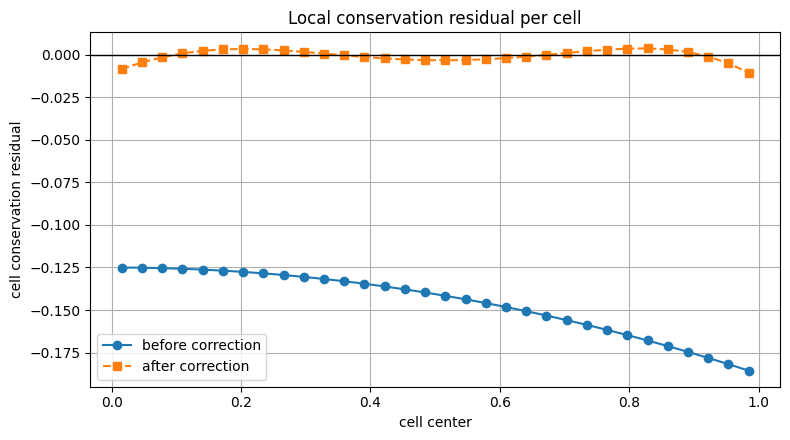

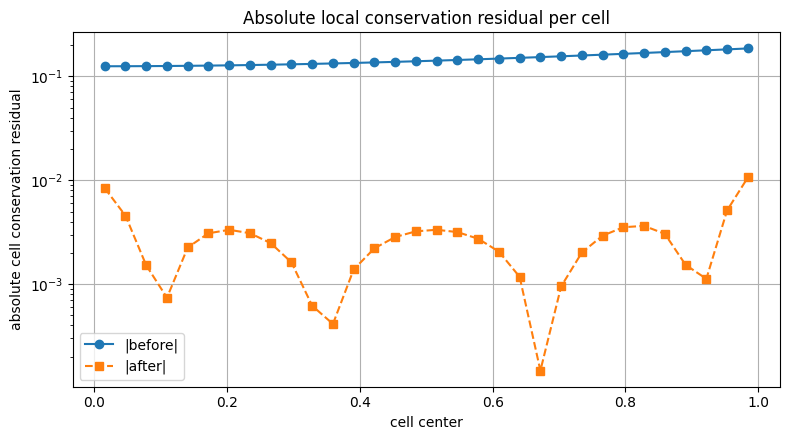

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim


# ------------------------------------------------------------
# Utilities for cellwise data from the FE solution
# ------------------------------------------------------------
def extract_cell_data_1d(domain, ph):
    """
    For each local cell, extract:
      - x_left, x_right, x_center
      - dp_h/dx (constant on the cell for P1)
    Gather everything on rank 0.
    """
    comm = domain.comm
    V = ph.function_space
    tdim = domain.topology.dim

    domain.topology.create_connectivity(tdim, 0)
    c_to_v = domain.topology.connectivity(tdim, 0)

    x_dofs = V.tabulate_dof_coordinates()[:, 0]
    u = ph.x.array

    num_cells_local = domain.topology.index_map(tdim).size_local

    x_left_local = np.zeros(num_cells_local, dtype=np.float64)
    x_right_local = np.zeros(num_cells_local, dtype=np.float64)
    x_center_local = np.zeros(num_cells_local, dtype=np.float64)
    dpdx_local = np.zeros(num_cells_local, dtype=np.float64)

    for cell in range(num_cells_local):
        cell_dofs = V.dofmap.cell_dofs(cell)
        x_cell = x_dofs[cell_dofs]
        u_cell = u[cell_dofs]

        idx = np.argsort(x_cell)
        x0, x1 = x_cell[idx]
        p0, p1 = u_cell[idx]

        h = x1 - x0
        dpdx = (p1 - p0) / h

        x_left_local[cell] = x0
        x_right_local[cell] = x1
        x_center_local[cell] = 0.5 * (x0 + x1)
        dpdx_local[cell] = dpdx

    gathered_left = comm.gather(x_left_local, root=0)
    gathered_right = comm.gather(x_right_local, root=0)
    gathered_center = comm.gather(x_center_local, root=0)
    gathered_dpdx = comm.gather(dpdx_local, root=0)

    if comm.rank == 0:
        x_left = np.concatenate(gathered_left)
        x_right = np.concatenate(gathered_right)
        x_center = np.concatenate(gathered_center)
        dpdx = np.concatenate(gathered_dpdx)

        idx = np.argsort(x_center)
        x_left = x_left[idx]
        x_right = x_right[idx]
        x_center = x_center[idx]
        dpdx = dpdx[idx]

        return x_left, x_right, x_center, dpdx

    return None, None, None, None


# ------------------------------------------------------------
# Problem-specific coefficient and source
# ------------------------------------------------------------
def K_fun_np(x):
    return 2.0 + x**2


def dKdx_fun_np(x):
    return 2.0 * x


def f_fun_np(x):
    # corrected source
    return 4.0 - 2.0 * x + 6.0 * x**2


def int_f_np(a, b):
    """
    Exact integral of f(x)=4-2x+6x^2 from a to b
    """
    Fb = 4.0 * b - b**2 + 2.0 * b**3
    Fa = 4.0 * a - a**2 + 2.0 * a**3
    return Fb - Fa


# ------------------------------------------------------------
# Small scalar neural network for flux correction r(x)
# ------------------------------------------------------------
class FluxCorrectionNet(nn.Module):
    def __init__(self, width=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )
        # Initialize last layer to zero
        last_layer = self.net[-1]
        nn.init.zeros_(last_layer.weight)
        nn.init.zeros_(last_layer.bias)

    def forward(self, x):
        return self.net(x)


# ------------------------------------------------------------
# Train r so that d/dx (K p_h' + r) = f at element centers
# ------------------------------------------------------------
def train_flux_correction(
    x_center,
    dpdx_center,
    epochs=5000,
    lr=1e-3,
    reg_lambda=1e-2,
    verbose_every=500,
):
    """
    Train scalar NN r(x) satisfying at collocation points x_c:
        d/dx (K(x) p_h'(cell) + r(x)) = f(x)

    Since dp_h/dx is constant on each cell, at the center:
        d/dx(K p_h') = K'(x_c) * p_h'(cell)

    so residual is:
        K'(x_c) * p_h'(cell) + r'(x_c) - f(x_c).
    """
    device = torch.device("cpu")

    xc = torch.tensor(x_center.reshape(-1, 1), dtype=torch.float64, device=device, requires_grad=True)
    dp = torch.tensor(dpdx_center.reshape(-1, 1), dtype=torch.float64, device=device)

    model = FluxCorrectionNet(width=16).to(device).double()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        r = model(xc)  # shape (N,1)

        drdx = torch.autograd.grad(
            r,
            xc,
            grad_outputs=torch.ones_like(r),
            create_graph=True,
            retain_graph=True,
        )[0]

        Kprime_dp = 2.0 * xc * dp
        fval = 4.0 - 2.0 * xc + 6.0 * xc**2

        residual = -Kprime_dp + drdx - fval

        loss_pde = torch.mean(residual**2)
        loss_reg = torch.mean(r**2)
        loss = loss_pde + reg_lambda * loss_reg

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:5d} | "
                f"loss = {loss.item():.6e} | "
                f"pde = {loss_pde.item():.6e} | "
                f"reg = {loss_reg.item():.6e}"
            )

    return model, loss_history


# ------------------------------------------------------------
# Compute local conservation after correction
# ------------------------------------------------------------
def compute_local_conservation_after_correction(domain, ph, model):
    """
    Compute cellwise corrected local conservation residual:

        R_i^corr = F_corr(x_R) - F_corr(x_L) - ∫_K f dx

    where
        F_corr(x) = K(x) p_h'(cell) + r(x)

    on each cell.
    """
    comm = domain.comm
    rank = comm.rank

    x_left, x_right, x_center, dpdx = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return None, None, None, None

    model.eval()

    with torch.no_grad():
        xL_t = torch.tensor(x_left.reshape(-1, 1), dtype=torch.float64)
        xR_t = torch.tensor(x_right.reshape(-1, 1), dtype=torch.float64)

        rL = model(xL_t).cpu().numpy().flatten()
        rR = model(xR_t).cpu().numpy().flatten()

    F_left = -K_fun_np(x_left) * dpdx + rL
    F_right = -K_fun_np(x_right) * dpdx + rR

    cell_integrals = int_f_np(x_left, x_right)

    residuals = F_right - F_left - cell_integrals
    abs_residuals = np.abs(residuals)

    return x_center, residuals, abs_residuals, {
        "F_left": F_left,
        "F_right": F_right,
        "r_left": rL,
        "r_right": rR,
    }


# ------------------------------------------------------------
# Compare before/after correction
# ------------------------------------------------------------
def compute_local_conservation_before_correction(domain, ph):
    """
    Raw local conservation residual using
        F_raw = K(x) p_h'(cell)
    """
    comm = domain.comm
    rank = comm.rank

    x_left, x_right, x_center, dpdx = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return None, None, None

    F_left = -K_fun_np(x_left) * dpdx
    F_right = -K_fun_np(x_right) * dpdx
    cell_integrals = int_f_np(x_left, x_right)

    residuals = F_right - F_left - cell_integrals
    abs_residuals = np.abs(residuals)

    return x_center, residuals, abs_residuals


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_training_history(loss_history):
    plt.figure(figsize=(7, 4.5))
    plt.semilogy(loss_history, linewidth=2)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training history for flux correction network")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_corrected_local_conservation(x_center, residual_before, residual_after):
    plt.figure(figsize=(8, 4.5))
    plt.plot(x_center, residual_before, "o-", label="before correction")
    plt.plot(x_center, residual_after, "s--", label="after correction")
    plt.axhline(0.0, color="k", linewidth=1)
    plt.xlabel("cell center")
    plt.ylabel("cell conservation residual")
    plt.title("Local conservation residual per cell")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.semilogy(x_center, np.abs(residual_before), "o-", label="|before|")
    plt.semilogy(x_center, np.abs(residual_after), "s--", label="|after|")
    plt.xlabel("cell center")
    plt.ylabel("absolute cell conservation residual")
    plt.title("Absolute local conservation residual per cell")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_flux_correction(model):
    x_plot = np.linspace(0.0, 1.0, 400)
    with torch.no_grad():
        xt = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float64)
        r_plot = model(xt).cpu().numpy().flatten()

    plt.figure(figsize=(7, 4.5))
    plt.plot(x_plot, r_plot, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("r(x)")
    plt.title("Learned flux correction")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main experiment: N = 32
# ------------------------------------------------------------
if __name__ == "__main__":
    N = 32

    # solve FE problem
    domain, ph, h, eL2, eH1 = solve_darcy_1d(N)

    # raw local conservation
    x_center_before, residual_before, abs_before = compute_local_conservation_before_correction(domain, ph)

    # training data from FE solution
    x_left, x_right, x_center, dpdx = extract_cell_data_1d(domain, ph)

    if MPI.COMM_WORLD.rank == 0:
        # train NN correction on element centers
        model, loss_history = train_flux_correction(
            x_center=x_center,
            dpdx_center=dpdx,
            epochs=10000,
            lr=5e-5,
            reg_lambda=1e-2,
            verbose_every=500,
        )

        # corrected local conservation
        x_center_after, residual_after, abs_after, extra = compute_local_conservation_after_correction(domain, ph, model)

        print("\nCellwise local conservation error:")
        print(f"{'center':>12} {'before':>18} {'after':>18}")
        print("-" * 52)
        for xc, rb, ra in zip(x_center_after, residual_before, residual_after):
            print(f"{xc:12.6f} {rb:18.10e} {ra:18.10e}")

        print("\nSummary:")
        print(f"max |residual before| = {np.max(abs_before):.10e}")
        print(f"max |residual after|  = {np.max(abs_after):.10e}")
        print(f"L2  |residual before| = {np.sqrt(np.sum(abs_before**2)):.10e}")
        print(f"L2  |residual after|  = {np.sqrt(np.sum(abs_after**2)):.10e}")

        plot_training_history(loss_history)
        plot_flux_correction(model)
        plot_corrected_local_conservation(x_center_after, residual_before, residual_after)

In [30]:
def q_exact_np(x):
    return -(2.0 + x**2) * (1.0 - 2.0 * x)


def compute_flux_L2_error_before_after(domain, ph, model, quad_degree=8):
    """
    Compute L2 flux error before and after correction:
        q_raw  = -K p_h'
        q_corr = -K p_h' - r(x)

    compared with exact flux
        q_exact = -(2+x^2)(1-2x)

    Returns on rank 0:
        err_raw, err_corr
    """
    comm = domain.comm
    rank = comm.rank

    x_left, x_right, x_center, dpdx = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return None, None

    model.eval()

    # Gauss-Legendre quadrature on reference interval [-1,1]
    xi_ref, w_ref = np.polynomial.legendre.leggauss(quad_degree)

    err_raw_sq = 0.0
    err_corr_sq = 0.0

    with torch.no_grad():
        for a, b, dp in zip(x_left, x_right, dpdx):
            # Map reference points to cell [a,b]
            xq = 0.5 * (b - a) * xi_ref + 0.5 * (a + b)
            jac = 0.5 * (b - a)

            # Raw flux: piecewise constant on the cell
            q_raw = -(2.0 + xq**2) * dp

            # Correction r(xq)
            xq_t = torch.tensor(xq.reshape(-1, 1), dtype=torch.float64)
            rq = model(xq_t).cpu().numpy().flatten()

            # Corrected flux consistent with training:
            # div(Kp' + r)=f  =>  q_corr = -(Kp' + r)
            q_corr = q_raw - rq

            q_ex = q_exact_np(xq)

            err_raw_sq += np.sum(w_ref * (q_raw - q_ex) ** 2) * jac
            err_corr_sq += np.sum(w_ref * (q_corr - q_ex) ** 2) * jac

    return np.sqrt(err_raw_sq), np.sqrt(err_corr_sq)

if MPI.COMM_WORLD.rank == 0:
    err_flux_raw, err_flux_corr = compute_flux_L2_error_before_after(domain, ph, model)

    print("\nFlux L2 error compared with exact flux q = -K p_exact':")
    print(f"||q_raw  - q_exact||_L2  = {err_flux_raw:.10e}")
    print(f"||q_corr - q_exact||_L2  = {err_flux_corr:.10e}")


Flux L2 error compared with exact flux q = -K p_exact':
||q_raw  - q_exact||_L2  = 4.2441829011e-02
||q_corr - q_exact||_L2  = 1.3307719165e+00


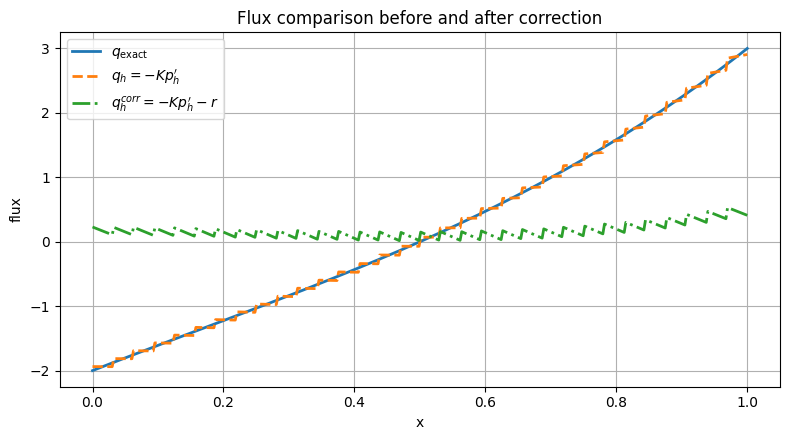

In [31]:
def plot_flux_comparison(domain, ph, model, nplot=400):
    comm = domain.comm
    rank = comm.rank

    x_left, x_right, x_center, dpdx = extract_cell_data_1d(domain, ph)

    if rank != 0:
        return

    x_plot = np.linspace(0.0, 1.0, nplot)
    q_raw_plot = np.zeros_like(x_plot)

    # piecewise constant dpdx by cell
    for i, x in enumerate(x_plot):
        # find containing cell
        cell_id = np.searchsorted(x_right, x, side="right")
        if cell_id >= len(dpdx):
            cell_id = len(dpdx) - 1
        q_raw_plot[i] = -(2.0 + x**2) * dpdx[cell_id]

    with torch.no_grad():
        xt = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float64)
        r_plot = model(xt).cpu().numpy().flatten()

    q_corr_plot = q_raw_plot - r_plot
    q_ex_plot = q_exact_np(x_plot)

    plt.figure(figsize=(8, 4.5))
    plt.plot(x_plot, q_ex_plot, label=r"$q_{\mathrm{exact}}$", linewidth=2)
    plt.plot(x_plot, q_raw_plot, "--", label=r"$q_h=-Kp_h'$", linewidth=2)
    plt.plot(x_plot, q_corr_plot, "-.", label=r"$q_h^{corr}=-Kp_h'-r$", linewidth=2)
    plt.xlabel("x")
    plt.ylabel("flux")
    plt.title("Flux comparison before and after correction")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_flux_comparison(domain, ph, model)